# Hero Vired — Python Graded Assignment
### Dataset: car_prices.csv | Subhash Adhikari | 9B_12349

---
## Section 1 — Data Ingestion & Quality Profiling

### 1.0 — Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully!')

Libraries imported successfully!


### 1.1 — Load & Inspect

In [7]:
df = pd.read_csv('car_prices.csv')

print('First 5 rows:')
display(df.head())

First 5 rows:


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [8]:
print('Data Types:')
print(df.dtypes)
print(f'\nTotal Records: {len(df):,}')

Data Types:
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object

Total Records: 558,837


### 1.2 — Understanding the Data Structure

In [9]:
print('Shape (rows x columns):', df.shape)
print('\nColumn Names and Data Types:')
print(df.dtypes)

Shape (rows x columns): (558837, 16)

Column Names and Data Types:
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


### 1.3 — Missing & Anomaly Detection

In [10]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})

print('Null values per column:')
display(null_df[null_df['Null Count'] > 0])

Null values per column:


,Null Count,Null %
make,10301,1.84
model,10399,1.86
trim,10651,1.91
body,13195,2.36
transmission,65352,11.69
vin,4,0.00
condition,11820,2.12
odometer,94,0.02
color,749,0.13
interior,749,0.13


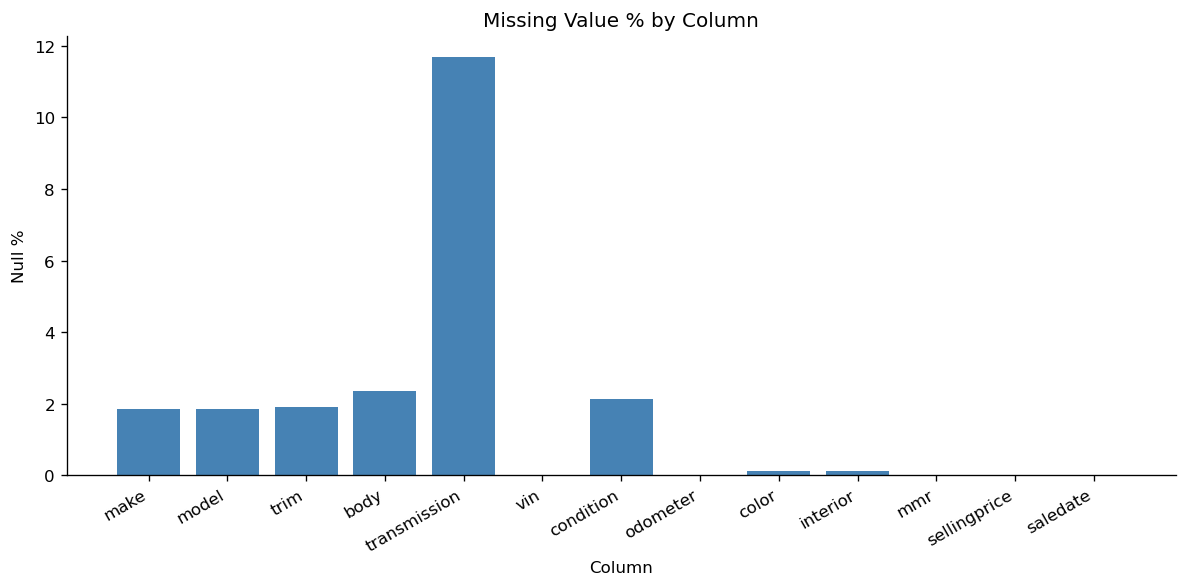

In [11]:
# Visualize missing values
plt.figure(figsize=(10, 5))
cols_with_nulls = null_df[null_df['Null Count'] > 0]
plt.bar(cols_with_nulls.index, cols_with_nulls['Null %'], color='steelblue')
plt.title('Missing Value % by Column')
plt.ylabel('Null %')
plt.xlabel('Column')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# Resolve null values
# Critical columns (very few nulls) → drop those rows
df.dropna(subset=['vin', 'sellingprice', 'saledate', 'mmr'], inplace=True)

# Numeric columns → fill with median (skew-safe)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → fill with mode (most frequent)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Remaining nulls after cleaning:', df.isnull().sum().sum())

Remaining nulls after cleaning: 0


In [13]:
# Count and remove duplicates
dup_count = df.duplicated().sum()
print(f'Duplicate rows found: {dup_count}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape after cleaning: {df.shape}')

Duplicate rows found: 0
Shape after cleaning: (558799, 16)


---
## Section 2 — DataFrame Queries

### 2.1 — Average, Minimum, and Maximum Car Price

In [14]:
avg_price = df['sellingprice'].mean()
min_price = df['sellingprice'].min()
max_price = df['sellingprice'].max()

print(f'Average Selling Price : ${avg_price:,.2f}')
print(f'Minimum Selling Price : ${min_price:,.2f}')
print(f'Maximum Selling Price : ${max_price:,.2f}')

Average Selling Price : $13,611.36
Minimum Selling Price : $1.00
Maximum Selling Price : $230,000.00


### 2.2 — All Unique Colors of Cars

In [15]:
unique_colors = df['color'].unique()
print(f'Total Unique Colors: {len(unique_colors)}')
print('Colors:', unique_colors)

Total Unique Colors: 20
Colors: ['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' 'orange' 'off-white'
 'turquoise' 'pink' 'lime']


### 2.3 — Unique Car Brands and Models

In [17]:
unique_brands_count = df['make'].nunique()
unique_models_count = df['model'].nunique()

print(f'Number of Unique Brands (Make): {unique_brands_count}')
print(f'Number of Unique Models       : {unique_models_count}')

Number of Unique Brands (Make): 96
Number of Unique Models       : 973


### 2.4 — Cars with Selling Price > $165,000

In [18]:
expensive_cars = df[df['sellingprice'] > 165000]
print(f'Total cars over $165,000: {len(expensive_cars)}')
display(expensive_cars[['make', 'model', 'year', 'sellingprice', 'state']])

Total cars over $165,000: 7


,make,model,year,sellingprice,state
125095,Rolls-Royce,Ghost,2012,169500.0,fl
344904,Ford,Escape,2014,230000.0,mo
446934,Mercedes-Benz,S-Class,2015,173000.0,ca
538313,Rolls-Royce,Ghost,2012,167000.0,ca
545488,Rolls-Royce,Ghost,2013,171500.0,fl
548134,Ferrari,458 Italia,2011,183000.0,fl
557532,Rolls-Royce,Ghost,2012,169000.0,ca


### 2.5 — Top 5 Most Frequently Sold Car Models

In [19]:
top_5_models = df['model'].value_counts().head(5)
print('Top 5 Most Frequently Sold Car Models:')
print(top_5_models.to_string())

Top 5 Most Frequently Sold Car Models:
model
Altima    29748
F-150     14479
Fusion    12945
Camry     12545
Escape    11861


### 2.6 — Average Selling Price by Brand (Make)

In [20]:
avg_price_by_brand = (df.groupby('make')['sellingprice']
                        .mean()
                        .sort_values(ascending=False)
                        .reset_index())
avg_price_by_brand.columns = ['Brand', 'Avg Selling Price ($)']
avg_price_by_brand['Avg Selling Price ($)'] = avg_price_by_brand['Avg Selling Price ($)'].round(2)
print('Average Selling Price by Brand (Top 10):')
display(avg_price_by_brand.head(10))

Average Selling Price by Brand (Top 10):


,Brand,Avg Selling Price ($)
0,Rolls-Royce,153488.24
1,Ferrari,127210.53
2,Lamborghini,112625.00
3,Bentley,74367.67
4,airstream,71000.00
5,Tesla,67054.35
6,Aston Martin,54812.00
7,Fisker,46461.11
8,Maserati,45320.30
9,Lotus,40800.00


### 2.7 — Minimum Selling Price by Interior Type

In [21]:
min_price_interior = (df.groupby('interior')['sellingprice']
                        .min()
                        .sort_values()
                        .reset_index())
min_price_interior.columns = ['Interior', 'Min Selling Price ($)']
print('Minimum Selling Price by Interior:')
display(min_price_interior)

Minimum Selling Price by Interior:


,Interior,Min Selling Price ($)
0,black,1.0
1,gray,1.0
2,beige,100.0
3,tan,100.0
4,green,100.0
5,silver,150.0
6,—,150.0
7,blue,150.0
8,burgundy,175.0
9,purple,200.0


### 2.8 — Highest Odometer Reading per Year (Descending)


In [22]:
highest_odo = (df.groupby('year')['odometer']
                 .max()
                 .sort_values(ascending=False)
                 .reset_index())
highest_odo.columns = ['Year', 'Max Odometer']
print('Highest Odometer per Year:')
display(highest_odo)

Highest Odometer per Year:


,Year,Max Odometer
0,1999,999999.0
1,2013,999999.0
2,2011,999999.0
3,2010,999999.0
4,2009,999999.0
5,2008,999999.0
6,2007,999999.0
7,2006,999999.0
8,2005,999999.0
9,2004,999999.0


### 2.9 — New Column: Car Age (Current Year = 2025)

In [23]:
df['car_age'] = 2025 - df['year']
print('car_age column added. Sample:')
display(df[['make', 'model', 'year', 'car_age']].head())

car_age column added. Sample:


,make,model,year,car_age
0,Kia,Sorento,2015,10
1,Kia,Sorento,2015,10
2,BMW,3 Series,2014,11
3,Volvo,S60,2015,10
4,BMW,6 Series Gran Coupe,2014,11


### 2.10 — Cars with Condition ≥ 48 AND Odometer > 90,000

In [24]:
filtered_cars = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]
print(f'Cars with condition >= 48 and odometer > 90,000: {len(filtered_cars)}')

Cars with condition >= 48 and odometer > 90,000: 746


### 2.11 — State with Consistently Higher Prices for Newer Cars (year > 2013)

In [25]:
newer_cars = df[df['year'] > 2013]
state_avg = (newer_cars.groupby('state')['sellingprice']
                       .agg(['mean', 'count'])
                       .query('count >= 100')  # min 100 listings for reliability
                       .sort_values('mean', ascending=False)
                       .reset_index())
state_avg.columns = ['State', 'Avg Price ($)', 'Listings']
state_avg['Avg Price ($)'] = state_avg['Avg Price ($)'].round(2)

print('Top 10 States — Avg Price for Newer Cars (year > 2013):')
display(state_avg.head(10))
print(f'\nState with consistently highest prices: {state_avg.iloc[0]["State"]}')

Top 10 States — Avg Price for Newer Cars (year > 2013):


,State,Avg Price ($),Listings
0,oh,28020.22,2755
1,ab,25204.26,141
2,nj,24237.06,3267
3,on,22962.56,1863
4,qc,22722.94,388
5,pa,22190.23,7173
6,tn,21841.68,5035
7,mi,21411.62,2050
8,ca,20951.32,9840
9,wa,20598.72,1407



State with consistently highest prices: oh


### 2.12 — Excellent Condition (Top 20%) — Best Value for Money Brands

In [26]:
top20_threshold = df['condition'].quantile(0.80)
excellent_cars = df[df['condition'] >= top20_threshold]

value_brands = (excellent_cars.groupby('make')['sellingprice']
                              .mean()
                              .sort_values()
                              .reset_index())
value_brands.columns = ['Brand', 'Avg Price ($)']
value_brands['Avg Price ($)'] = value_brands['Avg Price ($)'].round(2)

print(f'Condition threshold for Top 20% (Excellent): {top20_threshold}')
print('Best Value-for-Money Brands in Excellent Condition (Lowest Avg Price):')
display(value_brands.head(10))

Condition threshold for Top 20% (Excellent): 43.0
Best Value-for-Money Brands in Excellent Condition (Lowest Avg Price):


,Brand,Avg Price ($)
0,Isuzu,1125.00
1,Oldsmobile,1910.00
2,honda,4233.33
3,Saturn,5700.41
4,subaru,6200.00
5,chrysler,6225.00
6,smart,6835.76
7,mazda,7275.00
8,Pontiac,7686.82
9,Saab,7711.11


---
## Section 3 — Data Visualization & Insights

### 3.1 — Correlation Heatmap of Numerical Features

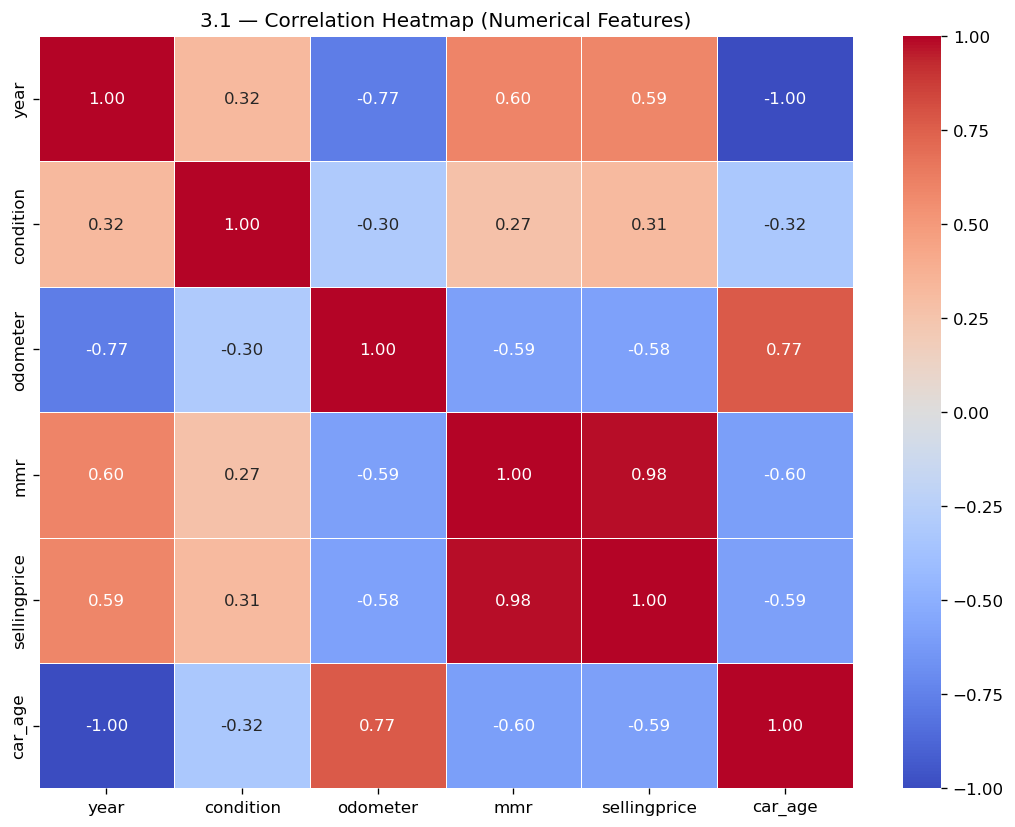

Insights:
1. sellingprice & mmr are strongly correlated (~0.98) — market value mirrors selling price.
2. odometer has mild negative correlation with sellingprice — higher mileage = lower price.
3. year has positive correlation with sellingprice — newer cars sell for more.


In [27]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('3.1 — Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

print('Insights:')
print('1. sellingprice & mmr are strongly correlated (~0.98) — market value mirrors selling price.')
print('2. odometer has mild negative correlation with sellingprice — higher mileage = lower price.')
print('3. year has positive correlation with sellingprice — newer cars sell for more.')

### 3.2 — Average Selling Price by Year
> **Bar chart chosen** — year is a discrete/categorical variable, not continuous.

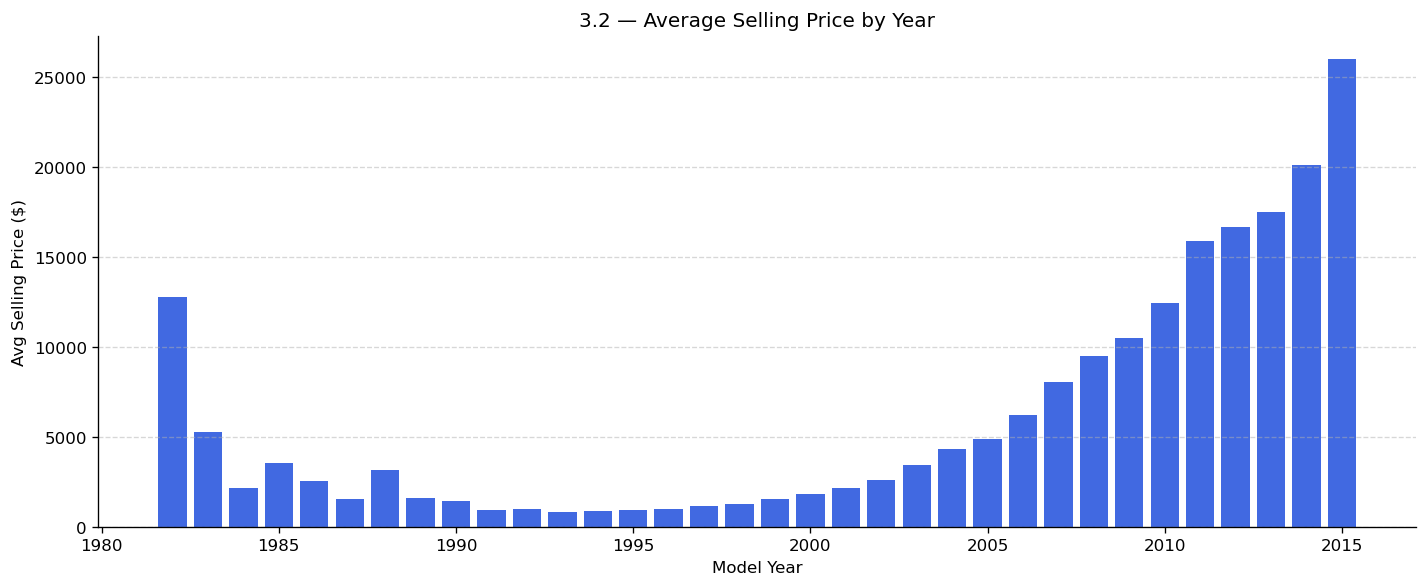

Insights:
1. Newer model years (2013-2015) command the highest average prices.
2. Sharp price drop observed for cars older than 2005 — rapid depreciation.
3. Bar chart used because year is a discrete category, not a continuous value.
4. Pattern: Clear upward trend in avg price as model year increases.


In [28]:
avg_price_year = df.groupby('year')['sellingprice'].mean().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(avg_price_year.index, avg_price_year.values, color='royalblue')
plt.title('3.2 — Average Selling Price by Year')
plt.xlabel('Model Year')
plt.ylabel('Avg Selling Price ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Insights:')
print('1. Newer model years (2013-2015) command the highest average prices.')
print('2. Sharp price drop observed for cars older than 2005 — rapid depreciation.')
print('3. Bar chart used because year is a discrete category, not a continuous value.')
print('4. Pattern: Clear upward trend in avg price as model year increases.')

### 3.3 — Average Selling Price by Odometer

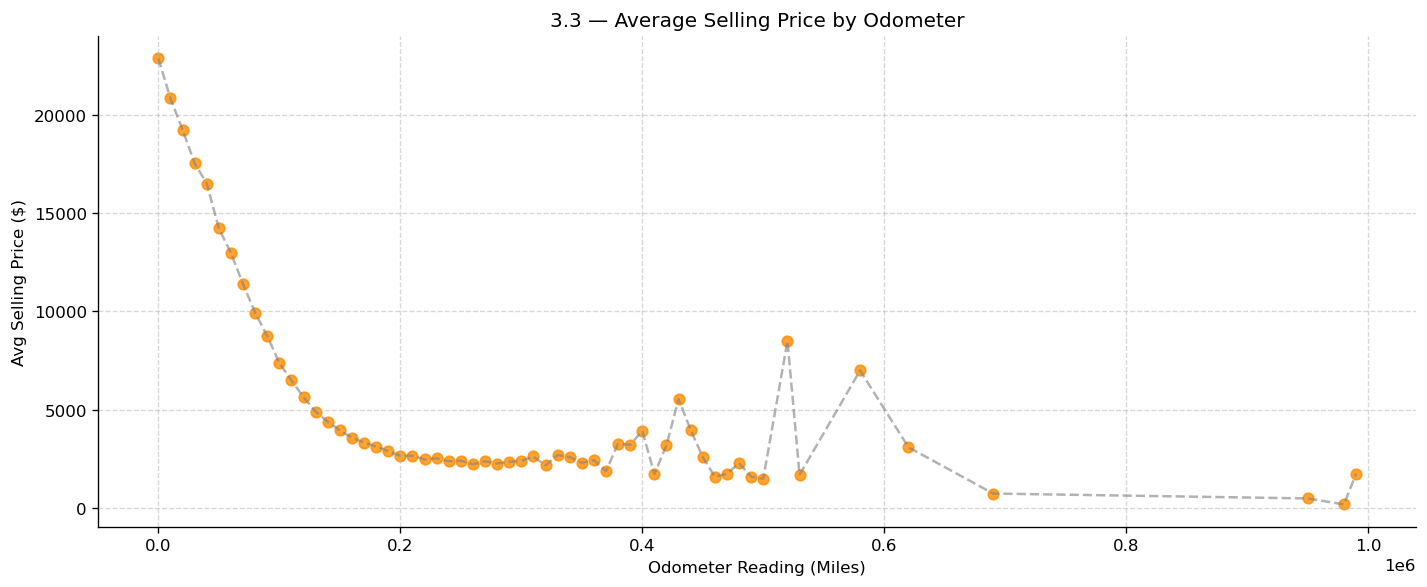

Insights:
1. Clear downward trend — as mileage increases, avg selling price drops consistently.
2. Cars with 0-20k miles sell at a significant premium over high-mileage ones.
3. Cars beyond 200k miles level off at very low prices — minimal further depreciation.


In [29]:
df['odometer_bin'] = (df['odometer'] // 10000) * 10000
avg_price_odo = df.groupby('odometer_bin')['sellingprice'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.scatter(avg_price_odo['odometer_bin'], avg_price_odo['sellingprice'],
            color='darkorange', s=40, alpha=0.8)
plt.plot(avg_price_odo['odometer_bin'], avg_price_odo['sellingprice'],
         color='gray', linestyle='--', alpha=0.6)
plt.title('3.3 — Average Selling Price by Odometer')
plt.xlabel('Odometer Reading (Miles)')
plt.ylabel('Avg Selling Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Insights:')
print('1. Clear downward trend — as mileage increases, avg selling price drops consistently.')
print('2. Cars with 0-20k miles sell at a significant premium over high-mileage ones.')
print('3. Cars beyond 200k miles level off at very low prices — minimal further depreciation.')

### 3.4 — Number of Cars Sold in Each State

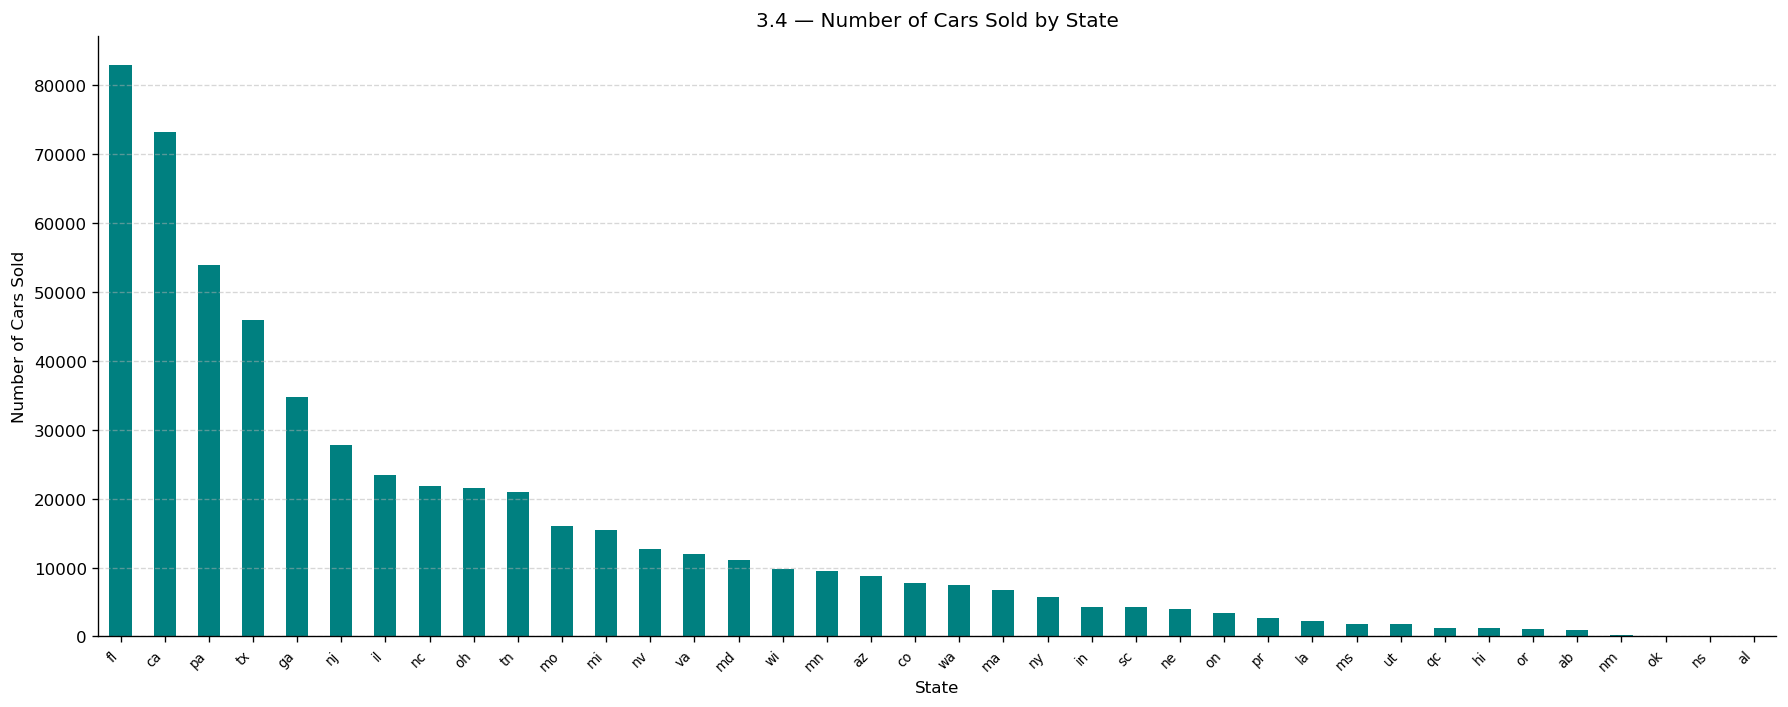

Top 3 States: ['fl', 'ca', 'pa'] with [np.int64(82945), np.int64(73148), np.int64(53907)] listings
FL (Florida), CA (California), PA (Pennsylvania) lead in car sales volume.


In [30]:
state_counts = df['state'].value_counts()

plt.figure(figsize=(15, 6))
state_counts.plot(kind='bar', color='teal')
plt.title('3.4 — Number of Cars Sold by State')
plt.xlabel('State')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

top3 = state_counts.head(3)
print(f'Top 3 States: {list(top3.index)} with {list(top3.values)} listings')
print('FL (Florida), CA (California), PA (Pennsylvania) lead in car sales volume.')

### 3.5 — Average Selling Price by Condition Score Range (size 5)


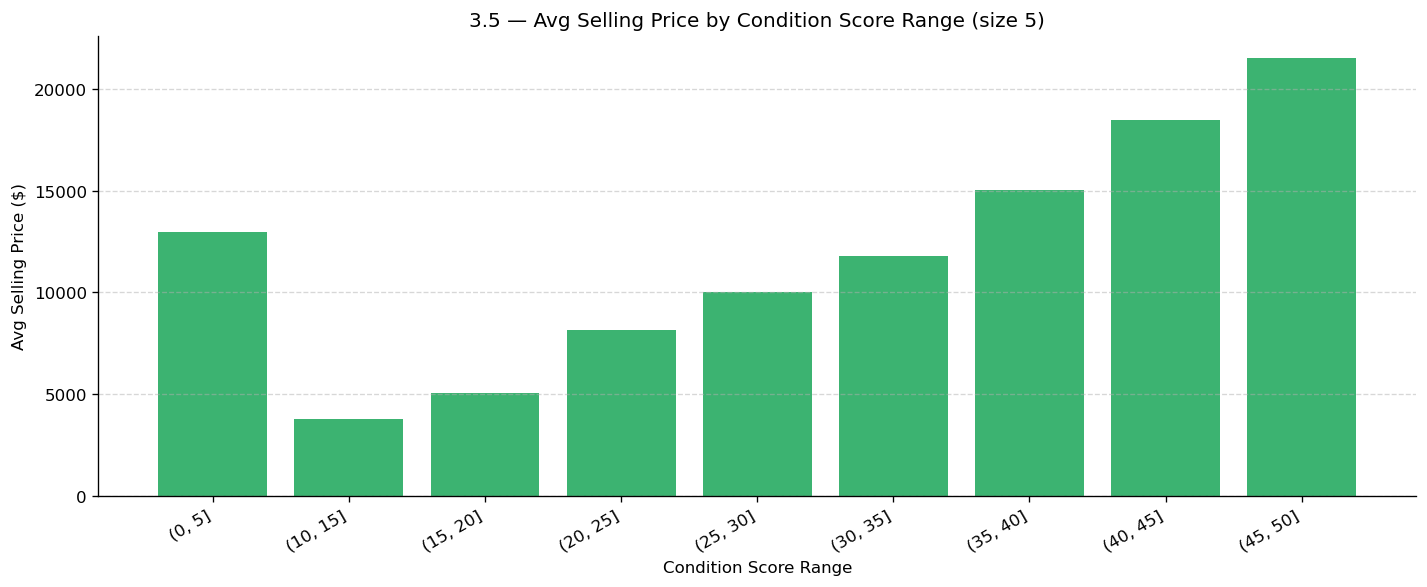

Insights:
1. Condition range (45-50) has the highest avg selling price — premium quality cars.
2. Clear positive relationship: better condition = higher price.
3. Condition below 20 shows very low avg prices — poor quality, low demand.
4. Most significant price jump happens between ranges 35-40 and 40-45.


In [31]:
# Using Interval type (NOT astype str) to preserve correct sort order
condition_bins = pd.cut(df['condition'], bins=np.arange(0, 55, 5))
avg_price_cond5 = df.groupby(condition_bins, observed=True)['sellingprice'].mean()

plt.figure(figsize=(12, 5))
plt.bar([str(k) for k in avg_price_cond5.index],
        avg_price_cond5.values, color='mediumseagreen')
plt.title('3.5 — Avg Selling Price by Condition Score Range (size 5)')
plt.xlabel('Condition Score Range')
plt.ylabel('Avg Selling Price ($)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Insights:')
print('1. Condition range (45-50) has the highest avg selling price — premium quality cars.')
print('2. Clear positive relationship: better condition = higher price.')
print('3. Condition below 20 shows very low avg prices — poor quality, low demand.')
print('4. Most significant price jump happens between ranges 35-40 and 40-45.')

### 3.6 — Number of Cars Sold by Condition Range (size 10)


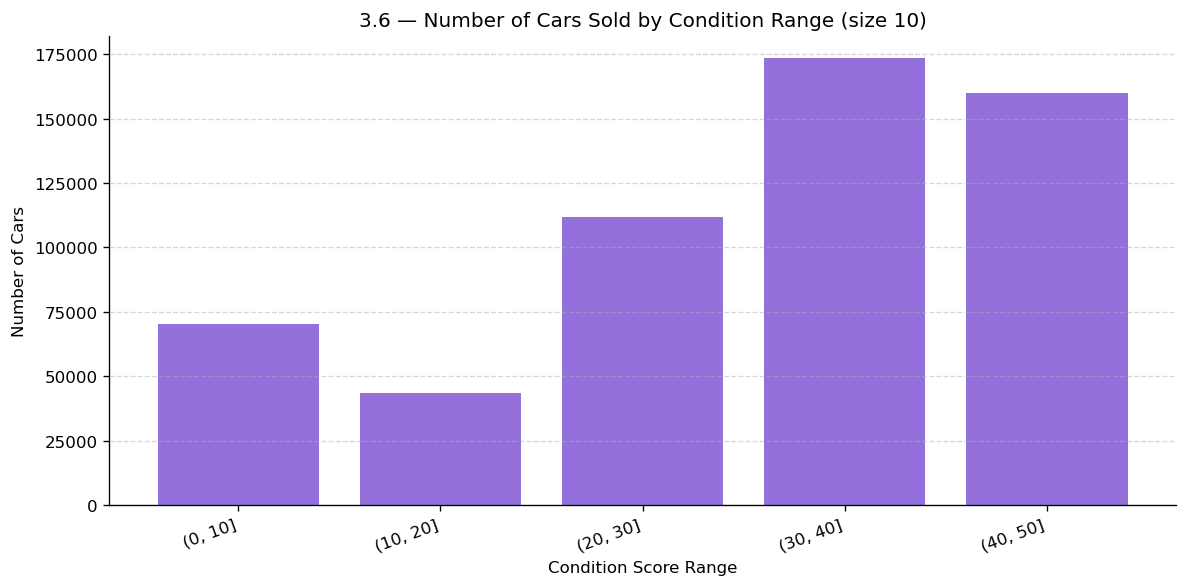

Insights:
1. (40-50) range has the most listings — majority of cars sold are in good condition.
2. Very few cars in (0-10) range — extremely poor condition cars rarely listed.
3. Dataset is heavily skewed toward higher-condition vehicles.
4. (30-40) is the second-largest bucket — large mid-quality used car market.


In [33]:
condition_bins10 = pd.cut(df['condition'], bins=np.arange(0, 60, 10))
count_cond10 = df.groupby(condition_bins10, observed=True)['sellingprice'].count()

plt.figure(figsize=(10, 5))
plt.bar([str(k) for k in count_cond10.index],
        count_cond10.values, color='mediumpurple')
plt.title('3.6 — Number of Cars Sold by Condition Range (size 10)')
plt.xlabel('Condition Score Range')
plt.ylabel('Number of Cars')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Insights:')
print('1. (40-50) range has the most listings — majority of cars sold are in good condition.')
print('2. Very few cars in (0-10) range — extremely poor condition cars rarely listed.')
print('3. Dataset is heavily skewed toward higher-condition vehicles.')
print('4. (30-40) is the second-largest bucket — large mid-quality used car market.')

### 3.7 — Box Plot: Selling Price Distribution by Color


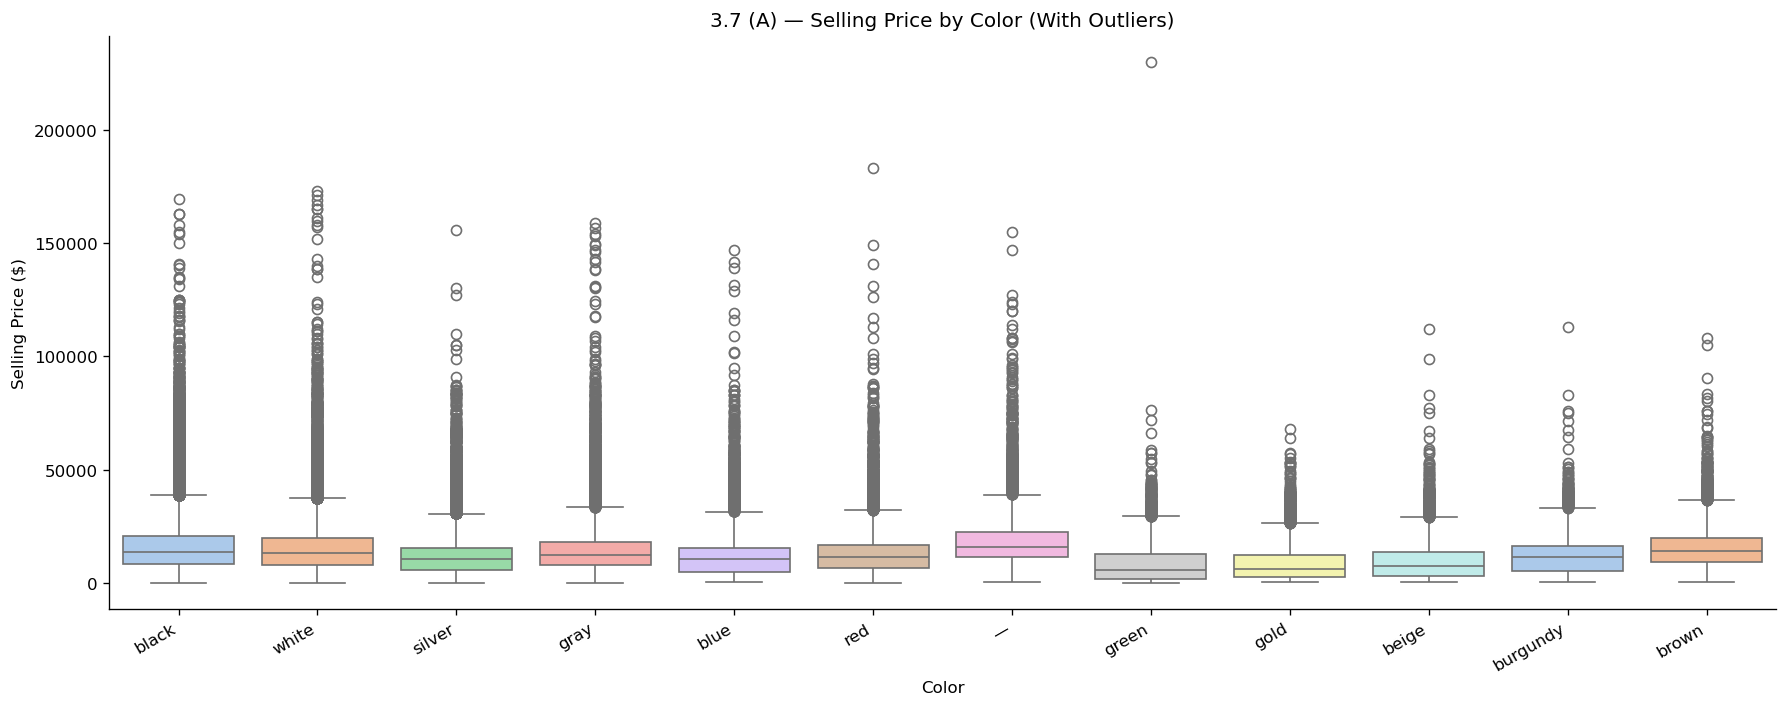

Insight 3.7(A): All colors show extreme outliers pulling the boxes up.
Outliers make it hard to compare true price distributions — removal needed.


In [34]:
# 3.7 A — With Outliers
top_colors = df['color'].value_counts().head(12).index
subset = df[df['color'].isin(top_colors)]

plt.figure(figsize=(15, 6))
sns.boxplot(data=subset, x='color', y='sellingprice',
            order=top_colors, palette='pastel')
plt.title('3.7 (A) — Selling Price by Color (With Outliers)')
plt.xlabel('Color')
plt.ylabel('Selling Price ($)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Insight 3.7(A): All colors show extreme outliers pulling the boxes up.')
print('Outliers make it hard to compare true price distributions — removal needed.')

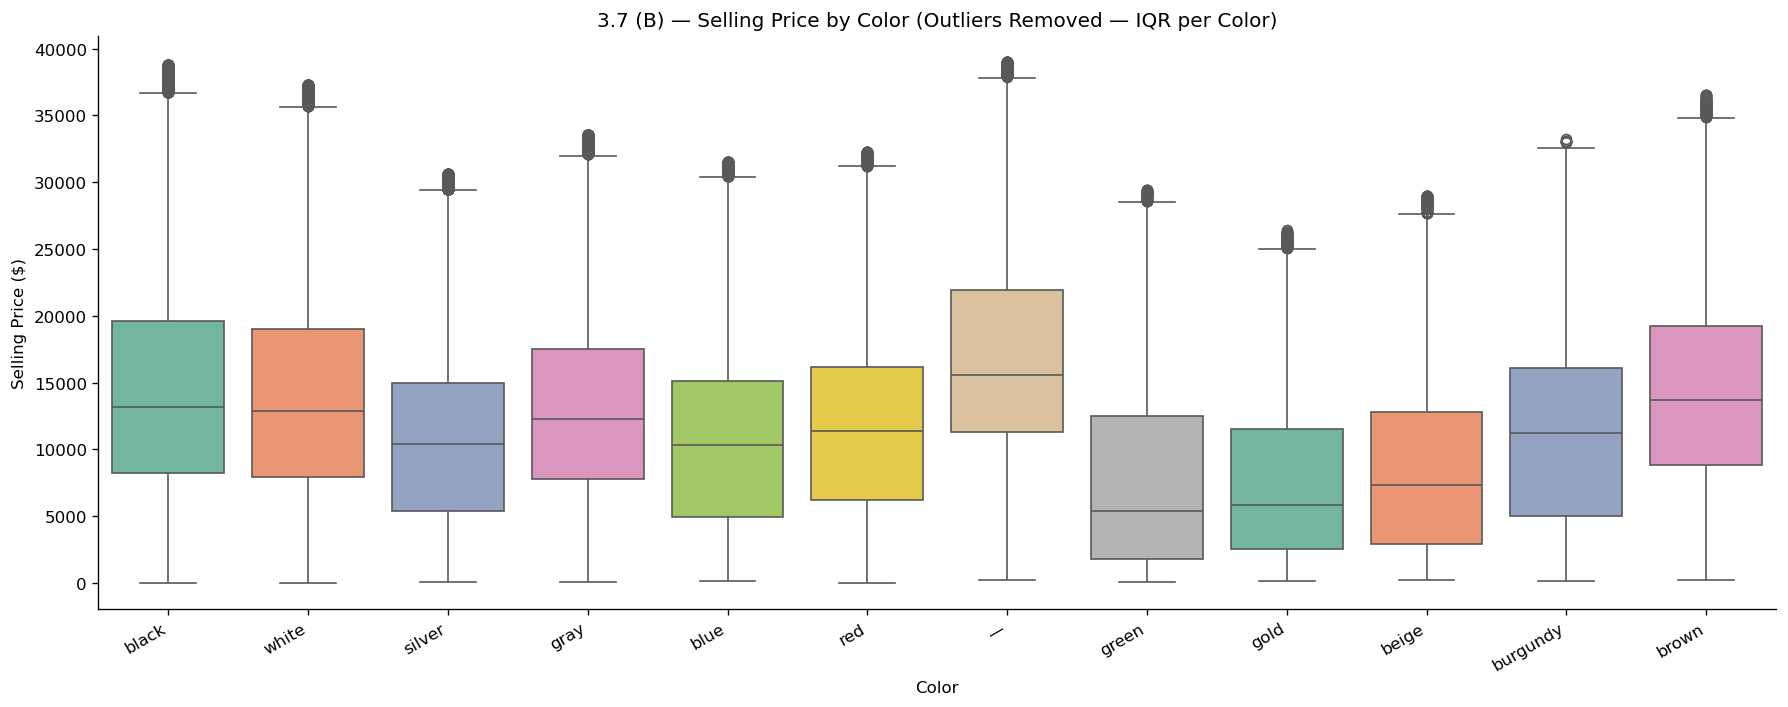

Insight 3.7(B):
1. After per-color IQR removal, distributions are clean and comparable.
2. Silver and white cars tend to have slightly higher median prices.
3. Beige and burgundy show lower median selling prices.
4. Most colors have similar spread — color is NOT a strong price driver.


In [35]:
# 3.7 B — Outliers removed using IQR per color group
q1 = subset.groupby('color')['sellingprice'].transform('quantile', 0.25)
q3 = subset.groupby('color')['sellingprice'].transform('quantile', 0.75)
iqr = q3 - q1
clean_subset = subset[
    (subset['sellingprice'] >= q1 - 1.5 * iqr) &
    (subset['sellingprice'] <= q3 + 1.5 * iqr)
].copy()

plt.figure(figsize=(15, 6))
sns.boxplot(data=clean_subset, x='color', y='sellingprice',
            order=[c for c in top_colors if c in clean_subset['color'].unique()],
            palette='Set2')
plt.title('3.7 (B) — Selling Price by Color (Outliers Removed — IQR per Color)')
plt.xlabel('Color')
plt.ylabel('Selling Price ($)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Insight 3.7(B):')
print('1. After per-color IQR removal, distributions are clean and comparable.')
print('2. Silver and white cars tend to have slightly higher median prices.')
print('3. Beige and burgundy show lower median selling prices.')
print('4. Most colors have similar spread — color is NOT a strong price driver.')